# Balanced LogReg Without Amount

In [3]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import recall_score, precision_score, f1_score, average_precision_score, confusion_matrix, PrecisionRecallDisplay
from itertools import combinations
import matplotlib.pyplot as plt
import seaborn as sns
import ast

In [4]:
DROPPED = ['Class', 'Time', 'Amount', 'V23', 'V27', 'V28', 'V26', 'V25', 'V22', 'V15', 'V13', 'V24']
TOP_N    = 12        
MIN_FEATURES = 3     

In [5]:
df = pd.read_csv('creditcard.csv')
ALL_FEATURES = [c for c in df.columns if c not in DROPPED]
print(f"Available features ({len(ALL_FEATURES)}): {ALL_FEATURES}\n")

X_all = df[ALL_FEATURES]
y     = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.3, stratify=y, random_state=42
)
X_eval, X_test, y_eval, y_test = train_test_split(
    X_test, y_test, test_size=0.5, stratify=y_test, random_state=42
)

def evaluate(features):
    model = LogisticRegression(max_iter=1000, class_weight='balanced')
    model.fit(X_train[list(features)], y_train)
    y_pred = model.predict(X_eval[list(features)])
    y_probs = model.predict_proba(X_eval[list(features)])[:, 1]
    return {
        'recall':    recall_score(y_eval, y_pred),
        'precision': precision_score(y_eval, y_pred),
        'f1':        f1_score(y_eval, y_pred),
        'pr_auc':    average_precision_score(y_eval, y_probs),
    }

results = []

Available features (19): ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V14', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21']



## FORWARD STEPWISE RECALL

In [18]:
print("Forward stepwise selection…\n")
selected   = []
remaining  = list(ALL_FEATURES)

while remaining:
    best_score  = -1
    best_feat   = None
    for feat in remaining:
        candidate = selected + [feat]
        if len(candidate) < MIN_FEATURES:
            # still track score but don't record yet
            m = evaluate(candidate)
            score = m["recall"]
        else:
            m = evaluate(candidate)
            score = m["recall"]
            results.append({'features': list(candidate), **m})

        if score > best_score:
            best_score = score
            best_feat  = feat
            best_metrics = m

    selected.append(best_feat)
    remaining.remove(best_feat)
    print(f"  Added '{best_feat}' → "
            f"recall={best_metrics['recall']:.4f}  "
            f"precision={best_metrics['precision']:.4f}  "
            f"f1={best_metrics['f1']:.4f}  "
            f"[{len(selected)} features]")

Forward stepwise selection…

  Added 'V14' → recall=0.8378  precision=0.0501  f1=0.0945  [1 features]
  Added 'V4' → recall=0.8784  precision=0.0447  f1=0.0851  [2 features]
  Added 'V2' → recall=0.8784  precision=0.0443  f1=0.0844  [3 features]
  Added 'V3' → recall=0.8784  precision=0.0448  f1=0.0852  [4 features]
  Added 'V5' → recall=0.8784  precision=0.0431  f1=0.0822  [5 features]
  Added 'V8' → recall=0.8919  precision=0.0449  f1=0.0855  [6 features]
  Added 'V6' → recall=0.8919  precision=0.0461  f1=0.0876  [7 features]
  Added 'V1' → recall=0.8919  precision=0.0461  f1=0.0877  [8 features]
  Added 'V7' → recall=0.8919  precision=0.0476  f1=0.0904  [9 features]
  Added 'V11' → recall=0.8919  precision=0.0544  f1=0.1026  [10 features]
  Added 'V9' → recall=0.8919  precision=0.0544  f1=0.1026  [11 features]
  Added 'V12' → recall=0.8919  precision=0.0581  f1=0.1092  [12 features]
  Added 'V10' → recall=0.8919  precision=0.0610  f1=0.1142  [13 features]
  Added 'V17' → recall=0.89

In [19]:
results_df = pd.DataFrame(results)
results_df['n_features'] = results_df['features'].apply(len)
results_df = results_df.sort_values("recall", ascending=False).reset_index(drop=True)

print("\n══════════════════════════════════════════════════════")
print(f"TOP 10 COMBINATIONS BY RECALl")
print("══════════════════════════════════════════════════════")
for i, row in results_df.head(10).iterrows():
    print(f"\nRank {i+1}  ({row['n_features']} features)")
    print(f"  Recall:    {row['recall']:.4f}")
    print(f"  Precision: {row['precision']:.4f}")
    print(f"  F1:        {row['f1']:.4f}")
    print(f"  PR AUC:    {row['pr_auc']:.4f}")
    print(f"  Features:  {row['features']}")

out_path = 'csv_new/logreg_fs_balanced_recall.csv'
results_df['features'] = results_df['features'].apply(str)
results_df.to_csv(out_path, index=False)
print(f"\nAll results saved to '{out_path}'")


══════════════════════════════════════════════════════
TOP 10 COMBINATIONS BY RECALl
══════════════════════════════════════════════════════

Rank 1  (16 features)
  Recall:    0.8919
  Precision: 0.0648
  F1:        0.1209
  PR AUC:    0.6363
  Features:  ['V14', 'V4', 'V2', 'V3', 'V5', 'V8', 'V6', 'V1', 'V7', 'V11', 'V9', 'V12', 'V10', 'V17', 'V16', 'V19']

Rank 2  (14 features)
  Recall:    0.8919
  Precision: 0.0604
  F1:        0.1132
  PR AUC:    0.6376
  Features:  ['V14', 'V4', 'V2', 'V3', 'V5', 'V8', 'V6', 'V1', 'V7', 'V11', 'V9', 'V12', 'V10', 'V21']

Rank 3  (11 features)
  Recall:    0.8919
  Precision: 0.0544
  F1:        0.1026
  PR AUC:    0.5767
  Features:  ['V14', 'V4', 'V2', 'V3', 'V5', 'V8', 'V6', 'V1', 'V7', 'V11', 'V20']

Rank 4  (11 features)
  Recall:    0.8919
  Precision: 0.0519
  F1:        0.0981
  PR AUC:    0.5821
  Features:  ['V14', 'V4', 'V2', 'V3', 'V5', 'V8', 'V6', 'V1', 'V7', 'V11', 'V21']

Rank 5  (12 features)
  Recall:    0.8919
  Precision: 0.058

## FORWARD STEPWISE PR AUC

In [20]:
print("Forward stepwise selection…\n")
selected   = []
remaining  = list(ALL_FEATURES)

while remaining:
    best_score  = -1
    best_feat   = None
    for feat in remaining:
        candidate = selected + [feat]
        if len(candidate) < MIN_FEATURES:
            # still track score but don't record yet
            m = evaluate(candidate)
            score = m["pr_auc"]
        else:
            m = evaluate(candidate)
            score = m["pr_auc"]
            results.append({'features': list(candidate), **m})

        if score > best_score:
            best_score = score
            best_feat  = feat
            best_metrics = m

    selected.append(best_feat)
    remaining.remove(best_feat)
    print(f"  Added '{best_feat}' → "
            f"recall={best_metrics['recall']:.4f}  "
            f"precision={best_metrics['precision']:.4f}  "
            f"f1={best_metrics['f1']:.4f}  "
            f"[{len(selected)} features]")

Forward stepwise selection…

  Added 'V14' → recall=0.8378  precision=0.0501  f1=0.0945  [1 features]
  Added 'V10' → recall=0.8378  precision=0.0613  f1=0.1142  [2 features]
  Added 'V8' → recall=0.8378  precision=0.0603  f1=0.1124  [3 features]
  Added 'V17' → recall=0.8378  precision=0.0660  f1=0.1224  [4 features]
  Added 'V16' → recall=0.8378  precision=0.0652  f1=0.1210  [5 features]
  Added 'V9' → recall=0.8378  precision=0.0720  f1=0.1326  [6 features]
  Added 'V2' → recall=0.8378  precision=0.0729  f1=0.1341  [7 features]
  Added 'V20' → recall=0.8378  precision=0.0727  f1=0.1338  [8 features]
  Added 'V18' → recall=0.8378  precision=0.0716  f1=0.1319  [9 features]
  Added 'V21' → recall=0.8514  precision=0.0707  f1=0.1306  [10 features]
  Added 'V19' → recall=0.8378  precision=0.0685  f1=0.1267  [11 features]
  Added 'V5' → recall=0.8514  precision=0.0650  f1=0.1208  [12 features]
  Added 'V6' → recall=0.8514  precision=0.0634  f1=0.1180  [13 features]
  Added 'V12' → recall=

In [21]:
results_df = pd.DataFrame(results)
results_df['n_features'] = results_df['features'].apply(len)
results_df = results_df.sort_values("pr_auc", ascending=False).reset_index(drop=True)

print("\n══════════════════════════════════════════════════════")
print(f"TOP 10 COMBINATIONS BY PR AUC")
print("══════════════════════════════════════════════════════")
for i, row in results_df.head(10).iterrows():
    print(f"\nRank {i+1}  ({row['n_features']} features)")
    print(f"  Recall:    {row['recall']:.4f}")
    print(f"  Precision: {row['precision']:.4f}")
    print(f"  F1:        {row['f1']:.4f}")
    print(f"  PR AUC:    {row['pr_auc']:.4f}")
    print(f"  Features:  {row['features']}")

out_path = 'csv_new/logreg_fs_balanced_pr_auc.csv'
results_df['features'] = results_df['features'].apply(str)
results_df.to_csv(out_path, index=False)
print(f"\nAll results saved to '{out_path}'")


══════════════════════════════════════════════════════
TOP 10 COMBINATIONS BY PR AUC
══════════════════════════════════════════════════════

Rank 1  (7 features)
  Recall:    0.8378
  Precision: 0.0729
  F1:        0.1341
  PR AUC:    0.6569
  Features:  ['V14', 'V10', 'V8', 'V17', 'V16', 'V9', 'V2']

Rank 2  (8 features)
  Recall:    0.8378
  Precision: 0.0727
  F1:        0.1338
  PR AUC:    0.6564
  Features:  ['V14', 'V10', 'V8', 'V17', 'V16', 'V9', 'V2', 'V20']

Rank 3  (8 features)
  Recall:    0.8378
  Precision: 0.0707
  F1:        0.1304
  PR AUC:    0.6563
  Features:  ['V14', 'V10', 'V8', 'V17', 'V16', 'V9', 'V2', 'V21']

Rank 4  (9 features)
  Recall:    0.8378
  Precision: 0.0716
  F1:        0.1319
  PR AUC:    0.6556
  Features:  ['V14', 'V10', 'V8', 'V17', 'V16', 'V9', 'V2', 'V20', 'V18']

Rank 5  (9 features)
  Recall:    0.8514
  Precision: 0.0717
  F1:        0.1322
  PR AUC:    0.6552
  Features:  ['V14', 'V10', 'V8', 'V17', 'V16', 'V9', 'V2', 'V20', 'V21']

Rank 6

## TOP N

In [22]:
print("Ranking features by logistic regression importance…")
base_model = LogisticRegression(max_iter=1000, class_weight='balanced')
base_model.fit(X_train, y_train)
importances = pd.Series(np.abs(base_model.coef_[0]), index=ALL_FEATURES)
top_features = importances.nlargest(TOP_N).index.tolist()
print(f"Top {TOP_N} features: {top_features}\n")

total = sum(1 for k in range(MIN_FEATURES, len(top_features)+1)
            for _ in combinations(top_features, k))
print(f"Exhaustive search over top {TOP_N}: {total:,} combinations…\n")
done = 0
for k in range(MIN_FEATURES, len(top_features) + 1):
    for combo in combinations(top_features, k):
        metrics = evaluate(combo)
        results.append({'features': list(combo), **metrics})
        done += 1
        if done % 200 == 0:
            print(f"  {done:,} / {total:,} done…")

Ranking features by logistic regression importance…
Top 12 features: ['V10', 'V4', 'V14', 'V12', 'V16', 'V17', 'V8', 'V11', 'V9', 'V1', 'V2', 'V21']

Exhaustive search over top 12: 4,017 combinations…

  200 / 4,017 done…
  400 / 4,017 done…
  600 / 4,017 done…
  800 / 4,017 done…
  1,000 / 4,017 done…
  1,200 / 4,017 done…
  1,400 / 4,017 done…
  1,600 / 4,017 done…
  1,800 / 4,017 done…
  2,000 / 4,017 done…
  2,200 / 4,017 done…
  2,400 / 4,017 done…
  2,600 / 4,017 done…
  2,800 / 4,017 done…
  3,000 / 4,017 done…
  3,200 / 4,017 done…
  3,400 / 4,017 done…
  3,600 / 4,017 done…
  3,800 / 4,017 done…
  4,000 / 4,017 done…


In [ ]:
results_df = pd.DataFrame(results)
results_df['n_features'] = results_df['features'].apply(len)
results_df = results_df.sort_values("recall", ascending=False).reset_index(drop=True)

print("\n══════════════════════════════════════════════════════")
print(f"TOP 10 COMBINATIONS BY RECALL (Top_N)")
print("══════════════════════════════════════════════════════")
for i, row in results_df.head(10).iterrows():
    print(f"\nRank {i+1}  ({row['n_features']} features)")
    print(f"  Recall:    {row['recall']:.4f}")
    print(f"  Precision: {row['precision']:.4f}")
    print(f"  F1:        {row['f1']:.4f}")
    print(f"  PR AUC:    {row['pr_auc']:.4f}")
    print(f"  Features:  {row['features']}")

out_path = 'csv_new/logreg_top_n_balanced_recall.csv'
results_df['features'] = results_df['features'].apply(str)
results_df.to_csv(out_path, index=False)
print(f"\nAll results saved to '{out_path}'")


══════════════════════════════════════════════════════
TOP 10 COMBINATIONS BY RECALl (Top_N)
══════════════════════════════════════════════════════

Rank 1  (14 features)
  Recall:    0.8919
  Precision: 0.0621
  F1:        0.1162
  PR AUC:    0.6293
  Features:  ['V14', 'V4', 'V2', 'V3', 'V5', 'V8', 'V6', 'V1', 'V7', 'V11', 'V9', 'V12', 'V10', 'V20']

Rank 2  (7 features)
  Recall:    0.8919
  Precision: 0.0521
  F1:        0.0984
  PR AUC:    0.6184
  Features:  ['V4', 'V14', 'V12', 'V8', 'V1', 'V2', 'V21']

Rank 3  (7 features)
  Recall:    0.8919
  Precision: 0.0537
  F1:        0.1012
  PR AUC:    0.6172
  Features:  ['V4', 'V14', 'V12', 'V8', 'V9', 'V2', 'V21']

Rank 4  (7 features)
  Recall:    0.8919
  Precision: 0.0510
  F1:        0.0966
  PR AUC:    0.6282
  Features:  ['V4', 'V14', 'V12', 'V8', 'V9', 'V1', 'V21']

Rank 5  (7 features)
  Recall:    0.8919
  Precision: 0.0537
  F1:        0.1014
  PR AUC:    0.6162
  Features:  ['V4', 'V14', 'V12', 'V8', 'V9', 'V1', 'V2']

R

In [24]:
results_df = pd.DataFrame(results)
results_df['n_features'] = results_df['features'].apply(len)
results_df = results_df.sort_values("pr_auc", ascending=False).reset_index(drop=True)

print("\n══════════════════════════════════════════════════════")
print(f"TOP 10 COMBINATIONS BY PR AUC (Top_N)")
print("══════════════════════════════════════════════════════")
for i, row in results_df.head(10).iterrows():
    print(f"\nRank {i+1}  ({row['n_features']} features)")
    print(f"  Recall:    {row['recall']:.4f}")
    print(f"  Precision: {row['precision']:.4f}")
    print(f"  F1:        {row['f1']:.4f}")
    print(f"  PR AUC:    {row['pr_auc']:.4f}")
    print(f"  Features:  {row['features']}")

out_path = 'csv_new/logreg_top_n_balanced_pr_auc.csv'
results_df['features'] = results_df['features'].apply(str)
results_df.to_csv(out_path, index=False)
print(f"\nAll results saved to '{out_path}'")


══════════════════════════════════════════════════════
TOP 10 COMBINATIONS BY PR AUC (Top_N)
══════════════════════════════════════════════════════

Rank 1  (7 features)
  Recall:    0.8378
  Precision: 0.0719
  F1:        0.1325
  PR AUC:    0.6589
  Features:  ['V10', 'V14', 'V16', 'V8', 'V9', 'V2', 'V21']

Rank 2  (9 features)
  Recall:    0.8784
  Precision: 0.0618
  F1:        0.1156
  PR AUC:    0.6578
  Features:  ['V10', 'V4', 'V14', 'V12', 'V16', 'V8', 'V11', 'V1', 'V21']

Rank 3  (6 features)
  Recall:    0.8378
  Precision: 0.0735
  F1:        0.1351
  PR AUC:    0.6572
  Features:  ['V10', 'V14', 'V16', 'V8', 'V9', 'V2']

Rank 4  (8 features)
  Recall:    0.8784
  Precision: 0.0607
  F1:        0.1135
  PR AUC:    0.6571
  Features:  ['V10', 'V4', 'V14', 'V12', 'V16', 'V8', 'V1', 'V2']

Rank 5  (9 features)
  Recall:    0.8784
  Precision: 0.0641
  F1:        0.1195
  PR AUC:    0.6571
  Features:  ['V10', 'V4', 'V14', 'V12', 'V16', 'V17', 'V8', 'V11', 'V1']

Rank 6  (10 f

# Compare the results

In [6]:


forward_stepwise = pd.read_csv('csv_new/logreg_fs_balanced_recall.csv')
forward_stepwise_pr_auc = pd.read_csv('csv_new/logreg_fs_balanced_pr_auc.csv')
top_n = pd.read_csv('csv_new/logreg_top_n_balanced_recall.csv')

fs_dataframes = {
    'recall': forward_stepwise,
    'pr_auc': forward_stepwise_pr_auc
}

best_of = ['recall', 'pr_auc']

for metric in best_of:
    fs = fs_dataframes[metric].sort_values(metric, ascending=False)
    top = top_n.sort_values(metric, ascending=False)

    print("\n══════════════════════════════════════════════════════")
    print(f'BEST OF {metric.upper()}  — SIDE BY SIDE')
    print("══════════════════════════════════════════════════════")
    metrics = ['recall', 'precision', 'f1', 'pr_auc']
    summary = pd.DataFrame({
        'Metric': metrics,
        f'Forward_Stepwise ({metric.upper()})': [fs[m].iloc[0] for m in metrics],
        f'Top_N ({metric.upper()})': [top[m].iloc[0] for m in metrics],
    })
    summary['Difference'] = summary[f'Top_N ({metric.upper()})'] - summary[f'Forward_Stepwise ({metric.upper()})']
    summary['Winner'] = summary['Difference'].apply(lambda x: f'Top_N ({metric.upper()})' if x > 0 else (f'Forward_Stepwise ({metric.upper()})' if x < 0 else 'Tie'))
    summary["Winner_Features"] = summary["Winner"].apply(
    lambda x: fs['features'].iloc[0] if "Forward_Stepwise" in x
    else (top['features'].iloc[0] if "Top_N" in x else top['features'].iloc[0] + "; " + fs['features'].iloc[0]))
    print(summary.to_string(index=False))


══════════════════════════════════════════════════════
BEST OF RECALL  — SIDE BY SIDE
══════════════════════════════════════════════════════
   Metric  Forward_Stepwise (RECALL)  Top_N (RECALL)  Difference                    Winner                                                                                                                                                                Winner_Features
   recall                   0.891892        0.891892    0.000000                       Tie ['V14', 'V4', 'V2', 'V3', 'V5', 'V8', 'V6', 'V1', 'V7', 'V11', 'V12']; ['V14', 'V4', 'V2', 'V3', 'V5', 'V8', 'V6', 'V1', 'V7', 'V11', 'V9', 'V12', 'V10', 'V17', 'V16', 'V19']
precision                   0.064833        0.058407   -0.006426 Forward_Stepwise (RECALL)                                                                        ['V14', 'V4', 'V2', 'V3', 'V5', 'V8', 'V6', 'V1', 'V7', 'V11', 'V9', 'V12', 'V10', 'V17', 'V16', 'V19']
       f1                   0.120879        0.109635   -0.01

# Generate HeatMap


ERGEBNISSE für Test: Balanced Forward Stepwise LogReg (Recall)
🔹 Recall:    0.8784  (Findet 87.8% der Betrugsfälle)
🔹 Precision: 0.0669  (6.7% der Alarme sind echt)
🔹 F1-Score:  0.1244
🔹 PR-AUC:    0.7743
🔹 Features:  ['V14', 'V4', 'V2', 'V3', 'V5', 'V8', 'V6', 'V1', 'V7', 'V11', 'V9', 'V12', 'V10', 'V17', 'V16', 'V19'], 16
---------------------------------------------



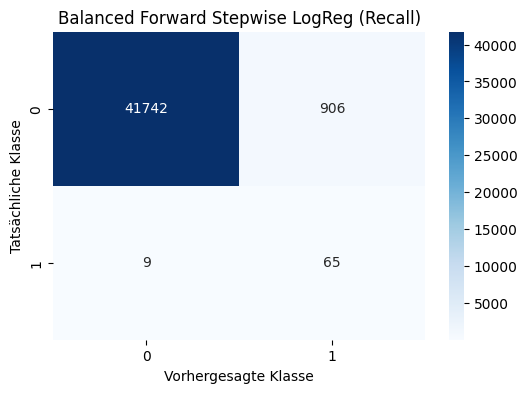

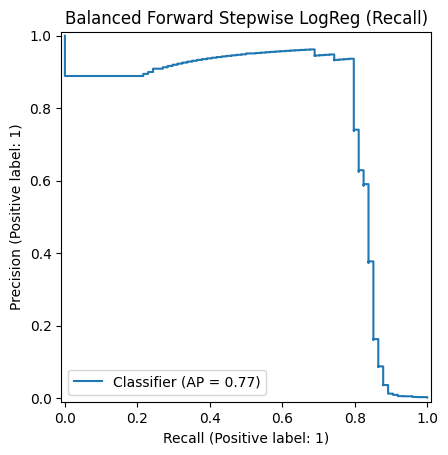

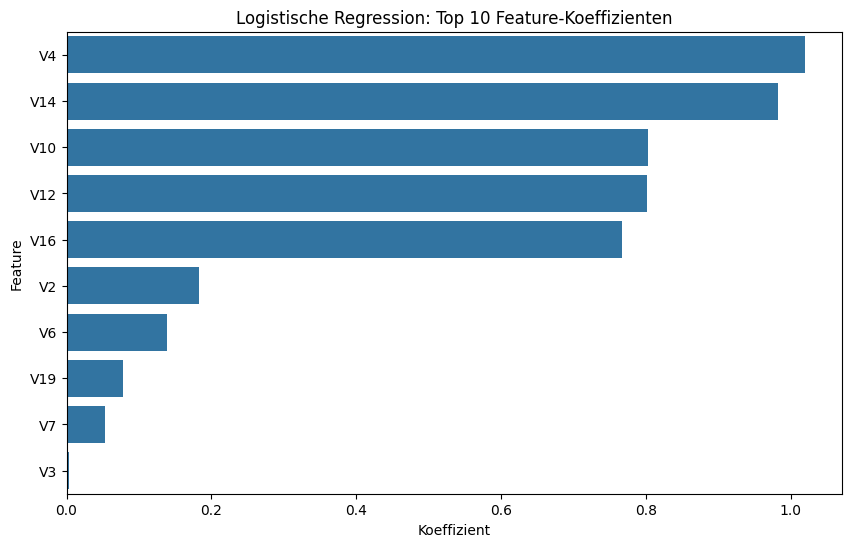


ERGEBNISSE für Test: Balanced Top N LogReg (Recall)
🔹 Recall:    0.8649  (Findet 86.5% der Betrugsfälle)
🔹 Precision: 0.0583  (5.8% der Alarme sind echt)
🔹 F1-Score:  0.1092
🔹 PR-AUC:    0.7136
🔹 Features:  ['V14', 'V4', 'V2', 'V3', 'V5', 'V8', 'V6', 'V1', 'V7', 'V11', 'V12'], 11
---------------------------------------------



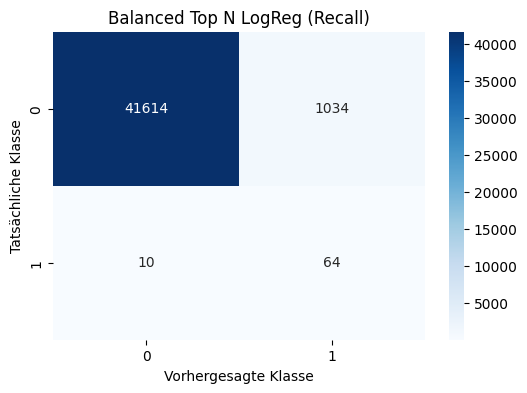

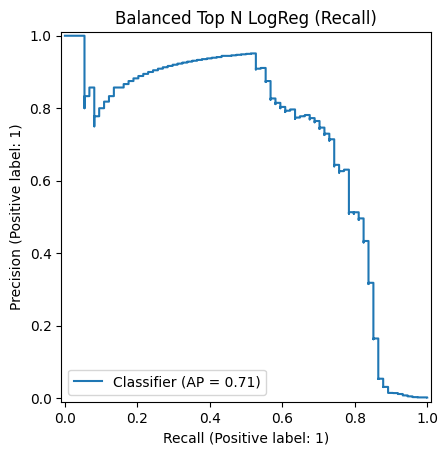

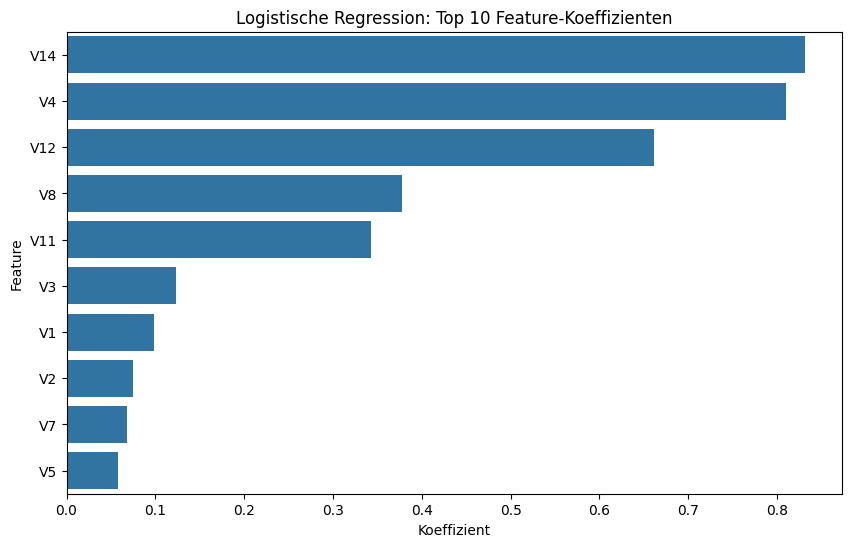


ERGEBNISSE für Test: Balanced Forward Stepwise LogReg (PR AUC)
🔹 Recall:    0.8514  (Findet 85.1% der Betrugsfälle)
🔹 Precision: 0.0776  (7.8% der Alarme sind echt)
🔹 F1-Score:  0.1422
🔹 PR-AUC:    0.7370
🔹 Features:  ['V14', 'V10', 'V8', 'V17', 'V16', 'V9', 'V2'], 7
---------------------------------------------



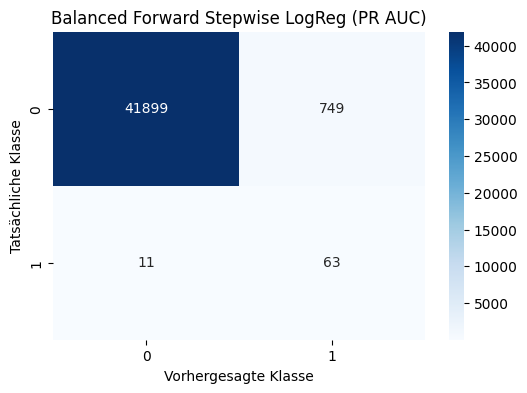

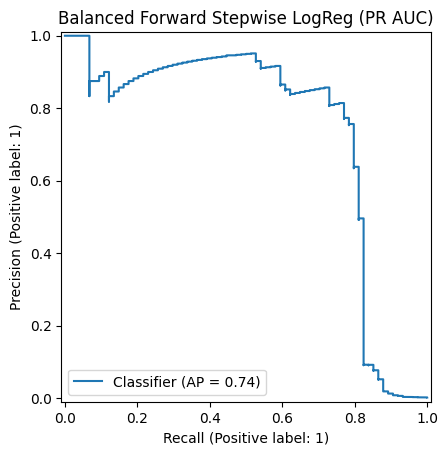

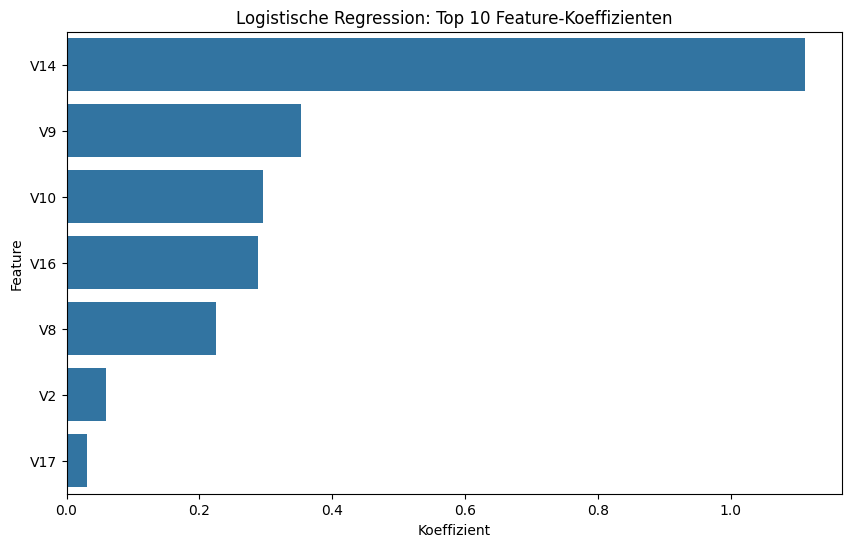


ERGEBNISSE für Test: Balanced Top N LogReg (PR AUC)
🔹 Recall:    0.8514  (Findet 85.1% der Betrugsfälle)
🔹 Precision: 0.0780  (7.8% der Alarme sind echt)
🔹 F1-Score:  0.1429
🔹 PR-AUC:    0.7370
🔹 Features:  ['V10', 'V14', 'V16', 'V8', 'V9', 'V2', 'V21'], 7
---------------------------------------------



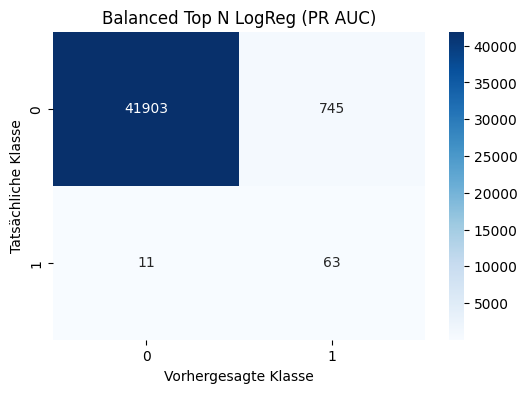

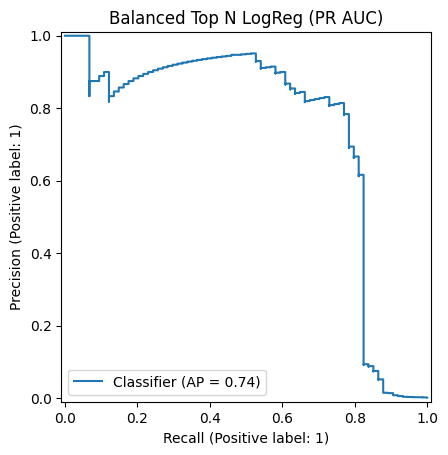

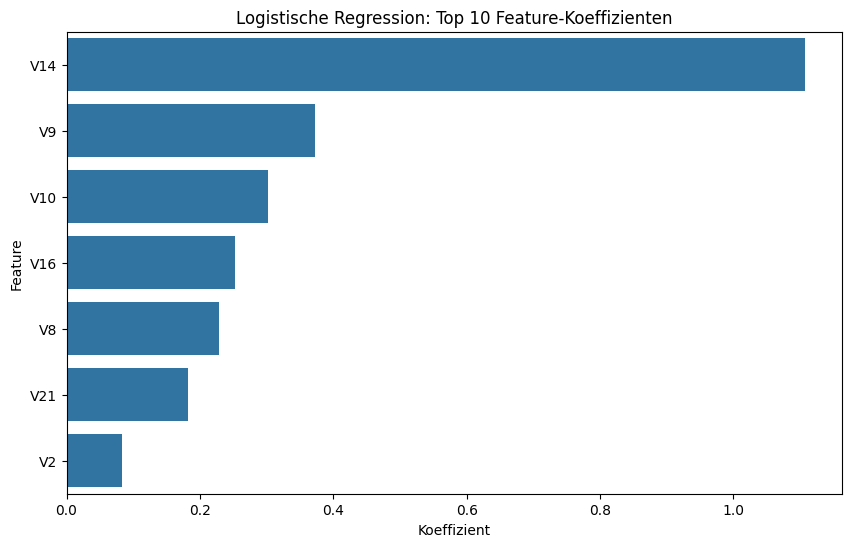

In [ ]:
def evaluate(features, title):
    model = LogisticRegression(max_iter=1000, class_weight='balanced')
    model.fit(X_train[list(features)], y_train)
    y_pred = model.predict(X_test[list(features)])
    y_probs = model.predict_proba(X_test[list(features)])[:, 1]

    recall = recall_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    pr_auc = average_precision_score(y_test, y_probs)

    # 1. SCHÖNE KONSOLENAUSGABE
    print(f"\n" + "="*45)
    print(f"ERGEBNISSE für Test: {title}")
    print(f"="*45)
    print(f"🔹 Recall:    {recall:.4f}  (Findet {recall*100:.1f}% der Betrugsfälle)")
    print(f"🔹 Precision: {precision:.4f}  ({precision*100:.1f}% der Alarme sind echt)")
    print(f"🔹 F1-Score:  {f1:.4f}")
    print(f"🔹 PR-AUC:    {pr_auc:.4f}")
    print(f"🔹 Features:  {features}, {len(features)}")
    print(f"-"*45 + "\n")

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(title)
    plt.ylabel('Tatsächliche Klasse')
    plt.xlabel('Vorhergesagte Klasse')
    plt.show()

    PrecisionRecallDisplay.from_predictions(y_test, y_probs)
    plt.title(title)
    plt.show()

    # Angenommen, dein trainiertes Modell heißt 'log_reg' und deine Features 'X_train'
    koeffizienten = abs(model.coef_[0])
    feature_names = model.feature_names_in_

    # Ein DataFrame daraus machen und nach Größe sortieren
    coef_df = pd.DataFrame({'Feature': feature_names, 'Koeffizient': koeffizienten})
    coef_df = coef_df.sort_values(by='Koeffizient', ascending=False)

    # Die Top 10 wichtigsten Features plotten (positiv und negativ)
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Koeffizient', y='Feature', data=pd.concat([coef_df.head(5), coef_df.tail(5)]))
    plt.title('Top 10 Feature-Koeffizienten - Logistische Regression')
    plt.show()

forward_stepwise_recall = forward_stepwise.sort_values("recall", ascending=False)
top_n_recall = top_n.sort_values("recall", ascending=False)

evaluate(ast.literal_eval(forward_stepwise_recall['features'].iloc[0]), "Balanced Forward Stepwise LogReg (Recall)")
evaluate(ast.literal_eval(top_n_recall['features'].iloc[0]), "Balanced Top N LogReg (Recall)")

forward_stepwise_pr_auc = forward_stepwise_pr_auc.sort_values("pr_auc", ascending=False)
top_n_pr_auc = top_n.sort_values("pr_auc", ascending=False)

evaluate(ast.literal_eval(forward_stepwise_pr_auc['features'].iloc[0]), "Balanced Forward Stepwise LogReg (PR AUC)")
evaluate(ast.literal_eval(top_n_pr_auc['features'].iloc[0]), "Balanced Top N LogReg (PR AUC)")